# 🗑️ Trash Validation System — Google Colab
## Class Waste Classification: Tidak Layak / Layak Diangkut /


**Alur:**
1. Install dependencies
2. Download dataset dari Roboflow
3. Train YOLOv8 detection model
4. Ekstrak fitur dari hasil deteksi
5. Train Random Forest 3-class classifier
6. Evaluasi & simpan semua model
7. Test inferensi end-to-end

In [ ]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================
!pip install ultralytics roboflow scikit-learn opencv-python-headless -q
!pip install albumentations scikit-image scipy -q

import torch
print(f'PyTorch   : {torch.__version__}')
print(f'CUDA      : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU       : {torch.cuda.get_device_name(0)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.6 MB/s eta 0:00:00
PyTorch   : 2.11.0+cu128
CUDA      : True
GPU       : Tesla T4


In [ ]:
# CELL 5a — Persiapan Anti-Runtime Putus
import torch
import gc

# 1. Kosongkan GPU memory
torch.cuda.empty_cache()
gc.collect()

# 2. Tampilkan status GPU
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Free GPU Memory: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")

# 3. Cek DATA_YAML sudah benar
from pathlib import Path
if 'DATA_YAML' not in dir():
    DATA_YAML = Path('/content/dataset/data.yaml')
print(f"Dataset YAML: {DATA_YAML}")
print(f"File exists: {DATA_YAML.exists()}")

In [ ]:
# CELL 5a.2 — BERSIHKAN GPU MEMORY (WAJIB!)
import torch
import gc

# Kosongkan semua memory GPU
torch.cuda.empty_cache()
gc.collect()

# Reset memory fragmentation
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.ipc_collect()

print(f"✅ GPU Memory setelah dibersihkan: {torch.cuda.memory_allocated()/1e9:.2f} GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"📊 Free: {torch.cuda.get_device_properties(0).total_memory/1e9 - torch.cuda.memory_allocated()/1e9:.2f} GB")

# Cek process apa yang pakai GPU
!nvidia-smi

✅ GPU Memory setelah dibersihkan: 0.54 GB / 15.6 GB
📊 Free: 15.09 GB
Thu Jun 25 01:06:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P0             26W /   70W |    1203MiB /  15360MiB |      9%      Default |
|                                         |                        |   

## CELL 2 — Download Dataset dari Roboflow

In [ ]:

from google.colab import files
import zipfile
from pathlib import Path
print("📁 Silakan upload file ZIP dataset kamu...")
uploaded = files.upload()

# Ambil nama file ZIP yang diupload
zip_filename = list(uploaded.keys())[0]
print(f"\n✅ File terupload: {zip_filename}")

# Tentukan folder ekstraksi
EXTRACT_DIR = Path('/content/dataset')
EXTRACT_DIR.mkdir(exist_ok=True)

# Ekstrak ZIP
print(f"📦 Mengekstrak ke {EXTRACT_DIR} ...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print(f"✅ Ekstraksi selesai!")

# ==== Deteksi otomatis root folder dataset ====
# (kalau di dalam ZIP ada subfolder, kita masuk ke dalamnya)
subdirs = [d for d in EXTRACT_DIR.iterdir() if d.is_dir()]
if len(subdirs) == 1 and not (EXTRACT_DIR / 'train').exists():
    DATA_DIR = subdirs[0]
    print(f"📂 Dataset root terdeteksi: {DATA_DIR}")
else:
    DATA_DIR = EXTRACT_DIR
    print(f"📂 Dataset root: {DATA_DIR}")

# Definisikan path split
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'valid'
TEST_DIR  = DATA_DIR / 'test'
DATA_YAML = DATA_DIR / 'data.yaml'

# Hitung jumlah file per split
print("\n📊 Ringkasan dataset:")
print(f"{'Split':<8} {'Images':>8} {'Labels':>8}")
print("-" * 26)
for split_name, split_path in [('train', TRAIN_DIR), ('valid', VAL_DIR), ('test', TEST_DIR)]:
    imgs = list((split_path / 'images').glob('*.*')) if (split_path / 'images').exists() else []
    lbls = list((split_path / 'labels').glob('*.txt')) if (split_path / 'labels').exists() else []
    status = "✅" if imgs else "⚠️ kosong"
    print(f"{split_name:<8} {len(imgs):>8} {len(lbls):>8}  {status}")

📁 Silakan upload file ZIP dataset kamu...


Saving Detect Garbage.v3i.yolov8.zip to Detect Garbage.v3i.yolov8.zip

✅ File terupload: Detect Garbage.v3i.yolov8.zip
📦 Mengekstrak ke /content/dataset ...
✅ Ekstraksi selesai!
📂 Dataset root: /content/dataset

📊 Ringkasan dataset:
Split      Images   Labels
--------------------------
train        2629     2629  ✅
valid         563      563  ✅
test          564      564  ✅


## CELL 3 — Fix data.yaml & Bersihkan Dataset

In [ ]:
# ============================================================
# CELL 3 — Preprocessing Dataset: Validasi, Bersihkan & Analisis
# ============================================================

import yaml
import shutil
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── 0. Konfigurasi ────────────────────────────────────────────
CLASS_NAMES = ['garbage']  # <-- GANTI SESUAI DATASET KAMU

SPLITS = {
    'train': TRAIN_DIR,
    'valid': VAL_DIR,
    'test' : TEST_DIR,
}

# ══════════════════════════════════════════════════════════════
# STEP 1 — Tulis / Perbaiki data.yaml
# ══════════════════════════════════════════════════════════════
print("=" * 55)
print("STEP 1: Menulis data.yaml")
print("=" * 55)

data_yaml_content = {
    'path'  : str(DATA_DIR),
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : len(CLASS_NAMES),
    'names' : CLASS_NAMES,
}
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"  ✅ data.yaml ditulis → {DATA_YAML}")
print(f"     nc    : {len(CLASS_NAMES)}")
print(f"     names : {CLASS_NAMES}")

STEP 1: Menulis data.yaml
  ✅ data.yaml ditulis → /content/dataset/data.yaml
     nc    : 1
     names : ['garbage']


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 2 — Bersihkan Orphan Files
# Orphan = label tanpa gambar, atau gambar tanpa label
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("STEP 2: Membersihkan Orphan Files")
print("=" * 55)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def clean_split(split_dir: Path, split_name: str):
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'

    if not images_dir.exists() or not labels_dir.exists():
        print(f"  ⚠️  SKIP '{split_name}' — folder tidak ditemukan")
        return 0, 0

    img_files = {f.stem: f for f in images_dir.iterdir()
                 if f.suffix.lower() in IMG_EXTS}
    lbl_files = {f.stem: f for f in labels_dir.glob('*.txt')}

    orphan_labels = set(lbl_files) - set(img_files)
    orphan_images = set(img_files) - set(lbl_files)

    for stem in orphan_labels:
        lbl_files[stem].unlink()
    for stem in orphan_images:
        img_files[stem].unlink()

    imgs_after = len(list(images_dir.glob('*.*')))
    lbls_after = len(list(labels_dir.glob('*.txt')))
    print(f"  ✅ {split_name:<6}: {imgs_after} images / {lbls_after} labels  "
          f"| dihapus → {len(orphan_labels)} orphan label, "
          f"{len(orphan_images)} orphan image")
    return imgs_after, lbls_after

for name, path in SPLITS.items():
    clean_split(path, name)


STEP 2: Membersihkan Orphan Files
  ✅ train : 2629 images / 2629 labels  | dihapus → 0 orphan label, 0 orphan image
  ✅ valid : 563 images / 563 labels  | dihapus → 0 orphan label, 0 orphan image
  ✅ test  : 564 images / 564 labels  | dihapus → 0 orphan label, 0 orphan image


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 3 — Deteksi & Hapus Gambar Duplikat (via MD5 hash)
# Mengapa penting: gambar duplikat membuat model 'menghafal'
# data tertentu, bukan belajar pola umum (overfitting).
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("STEP 3: Deteksi Duplikat Gambar")
print("=" * 55)

def file_hash(filepath: Path) -> str:
    """MD5 hash dari isi file — identik = duplikat."""
    h = hashlib.md5()
    with open(filepath, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

hash_map = defaultdict(list)  # hash → list path file

for name, split_dir in SPLITS.items():
    images_dir = split_dir / 'images'
    if not images_dir.exists():
        continue
    for img_path in images_dir.iterdir():
        if img_path.suffix.lower() in IMG_EXTS:
            h = file_hash(img_path)
            hash_map[h].append((name, img_path))

total_dupes = 0
for h, entries in hash_map.items():
    if len(entries) > 1:
        total_dupes += len(entries) - 1
        print(f"  ⚠️  Duplikat ditemukan ({len(entries)}x): {[str(e[1].name) for e in entries]}")
        # Hapus semua kecuali yang pertama
        for split_name, dup_path in entries[1:]:
            lbl_path = SPLITS[split_name] / 'labels' / (dup_path.stem + '.txt')
            dup_path.unlink()
            if lbl_path.exists():
                lbl_path.unlink()
            print(f"     🗑️  Dihapus: {dup_path}")

if total_dupes == 0:
    print("  ✅ Tidak ada duplikat ditemukan")
else:
    print(f"  🗑️  Total duplikat dihapus: {total_dupes}")


STEP 3: Deteksi Duplikat Gambar
  ✅ Tidak ada duplikat ditemukan


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 4 — Validasi Label YOLO
# Format label YOLO: class_id cx cy w h (semua 0.0–1.0)
# Error umum: koordinat > 1, negatif, atau width/height = 0
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("STEP 4: Validasi Label YOLO (koordinat bounding box)")
print("=" * 55)

def validate_labels(split_dir: Path, split_name: str, nc: int):
    labels_dir = split_dir / 'labels'
    if not labels_dir.exists():
        return

    error_files = []
    fixed_count = 0
    total_boxes = 0

    for lbl_file in labels_dir.glob('*.txt'):
        lines = lbl_file.read_text().strip().splitlines()
        new_lines = []
        file_has_error = False

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                file_has_error = True
                continue  # skip baris malformat

            cls_id, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])

            # Validasi class id
            if cls_id < 0 or cls_id >= nc:
                file_has_error = True
                continue

            # Clamp koordinat ke [0.0, 1.0]
            cx = max(0.0, min(1.0, cx))
            cy = max(0.0, min(1.0, cy))
            w  = max(0.001, min(1.0, w))   # width minimal 0.001
            h  = max(0.001, min(1.0, h))   # height minimal 0.001

            # Pastikan box tidak keluar gambar
            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2
            if x1 < 0: cx -= x1         # geser agar tidak keluar kiri
            if y1 < 0: cy -= y1         # geser agar tidak keluar atas
            if x2 > 1: cx -= (x2 - 1)  # geser agar tidak keluar kanan
            if y2 > 1: cy -= (y2 - 1)  # geser agar tidak keluar bawah

            new_lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
            total_boxes += 1

        if file_has_error:
            error_files.append(lbl_file.name)
            fixed_count += 1

        # Tulis ulang label yang sudah diperbaiki
        lbl_file.write_text('\n'.join(new_lines))

    print(f"  ✅ {split_name:<6}: {total_boxes} bounding box valid  "
          f"| {fixed_count} file diperbaiki"
          + (f"  ⚠️  [{', '.join(error_files[:3])}{'...' if len(error_files)>3 else ''}]"
             if error_files else ""))

for name, path in SPLITS.items():
    validate_labels(path, name, nc=len(CLASS_NAMES))


STEP 4: Validasi Label YOLO (koordinat bounding box)
  ✅ train : 6414 bounding box valid  | 17 file diperbaiki  ⚠️  [img1451_jpg.rf.028e450ff4d94ccc2c8410c7e446c9c6.txt, img240_jpg.rf.dbf65ac6edf674965167249cf80e39c4.txt, img1333_jpg.rf.818755589a25287117bf22beb278708f.txt...]
  ✅ valid : 1322 bounding box valid  | 4 file diperbaiki  ⚠️  [img1134_jpg.rf.6549b878809e2a280f88ee3c83f113ba.txt, img269_jpg.rf.96fdf4e4a6f75e446fe0704477039549.txt, img1008_jpg.rf.4a22894c497c585f7e571d697b391ab8.txt...]
  ✅ test  : 1124 bounding box valid  | 3 file diperbaiki  ⚠️  [img1358_jpg.rf.435eccfefd5a880d7d4a2cfceab9a08b.txt, img260_jpg.rf.3a4a3eb44b77c64de38f425267a73b78.txt, img1157_jpg.rf.d1b13e6161979ec2e63f4a58b2241b8c.txt]


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 5 — Cek Gambar Korup
# Gambar korup = tidak bisa dibuka oleh OpenCV.
# Jika dibiarkan, DataLoader akan crash saat training.
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("STEP 5: Cek Gambar Korup")
print("=" * 55)

def check_corrupt_images(split_dir: Path, split_name: str):
    images_dir = split_dir / 'images'
    if not images_dir.exists():
        return

    corrupt = []
    for img_path in images_dir.iterdir():
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            corrupt.append(img_path)

    for p in corrupt:
        lbl = split_dir / 'labels' / (p.stem + '.txt')
        p.unlink()
        if lbl.exists():
            lbl.unlink()
        print(f"  🗑️  Korup & dihapus: {p.name}")

    total = len(list(images_dir.glob('*.*')))
    print(f"  ✅ {split_name:<6}: {total} gambar valid  "
          f"| {len(corrupt)} gambar korup dihapus")

for name, path in SPLITS.items():
    check_corrupt_images(path, name)


STEP 5: Cek Gambar Korup
  ✅ train : 2629 gambar valid  | 0 gambar korup dihapus
  ✅ valid : 563 gambar valid  | 0 gambar korup dihapus
  ✅ test  : 564 gambar valid  | 0 gambar korup dihapus


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 6 — Analisis Distribusi Kelas & Ukuran Bounding Box
# Mengapa penting: class imbalance menyebabkan model bias
# ke kelas yang lebih banyak datanya.
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("STEP 6: Analisis Distribusi Kelas & Ukuran Box")
print("=" * 55)

class_counter = Counter()
box_widths, box_heights = [], []

for name, split_dir in SPLITS.items():
    labels_dir = split_dir / 'labels'
    if not labels_dir.exists():
        continue
    for lbl_file in labels_dir.glob('*.txt'):
        for line in lbl_file.read_text().strip().splitlines():
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                class_counter[CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)] += 1
                box_widths.append(float(parts[3]))
                box_heights.append(float(parts[4]))

print(f"\n  {'Kelas':<20} {'Jumlah Box':>12} {'Proporsi':>10}")
print(f"  {'-'*44}")
total_boxes = sum(class_counter.values())
for cls, count in sorted(class_counter.items(), key=lambda x: -x[1]):
    pct = count / total_boxes * 100
    bar = '█' * int(pct / 2)
    print(f"  {cls:<20} {count:>12,}   {pct:>6.1f}%  {bar}")

if box_widths:
    print(f"\n  Ukuran Bounding Box (relatif terhadap gambar):")
    print(f"    Lebar  — min: {min(box_widths):.3f}  max: {max(box_widths):.3f}  "
          f"rata-rata: {np.mean(box_widths):.3f}")
    print(f"    Tinggi — min: {min(box_heights):.3f}  max: {max(box_heights):.3f}  "
          f"rata-rata: {np.mean(box_heights):.3f}")

    small = sum(1 for w, h in zip(box_widths, box_heights) if w < 0.05 or h < 0.05)
    if small > 0:
        print(f"  ⚠️  {small} box sangat kecil (<5% ukuran gambar) — "
              f"pertimbangkan imgsz=1280")


STEP 6: Analisis Distribusi Kelas & Ukuran Box

  Kelas                  Jumlah Box   Proporsi
  --------------------------------------------
  garbage                     8,860    100.0%  ██████████████████████████████████████████████████

  Ukuran Bounding Box (relatif terhadap gambar):
    Lebar  — min: 0.002  max: 1.000  rata-rata: 0.322
    Tinggi — min: 0.001  max: 1.000  rata-rata: 0.261
  ⚠️  832 box sangat kecil (<5% ukuran gambar) — pertimbangkan imgsz=1280



STEP 7: Visualisasi Sampel Label


/tmp/ipykernel_564/1164822281.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap('tab10', len(CLASS_NAMES))


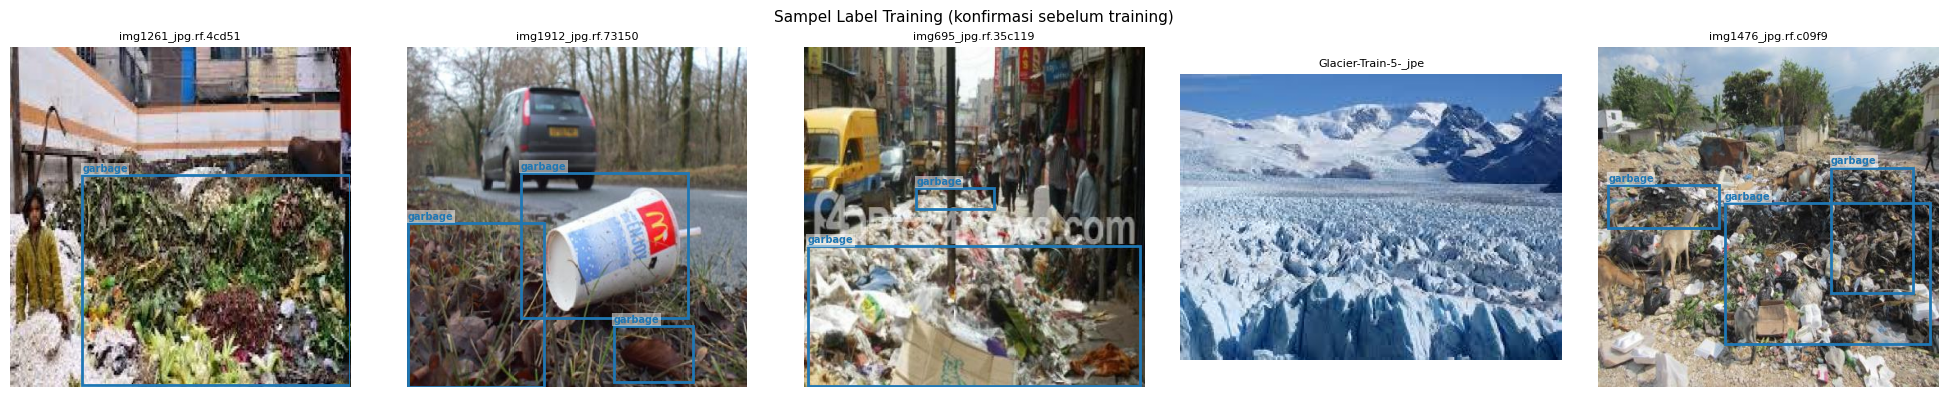

  ✅ Visualisasi selesai

RINGKASAN DATASET FINAL

  Split      Images   Labels
  --------------------------
  train        2629     2629
  valid         563      563
  test          564      564

  Total kelas : 1
  Total box   : 8,860

✅ Preprocessing selesai — dataset siap untuk training!


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 7 — Visualisasi Sampel (5 gambar dari train)
# Konfirmasi visual: label sudah benar sebelum training dimulai
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("STEP 7: Visualisasi Sampel Label")
print("=" * 55)

def visualize_samples(split_dir: Path, n: int = 5):
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'
    if not images_dir.exists():
        return

    img_files = [f for f in images_dir.iterdir()
                 if f.suffix.lower() in IMG_EXTS][:n]
    if not img_files:
        print("  ⚠️  Tidak ada gambar untuk divisualisasikan")
        return

    fig, axes = plt.subplots(1, len(img_files), figsize=(4 * len(img_files), 4))
    if len(img_files) == 1:
        axes = [axes]

    COLORS = plt.cm.get_cmap('tab10', len(CLASS_NAMES))

    for ax, img_path in zip(axes, img_files):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        H, W = img_rgb.shape[:2]

        ax.imshow(img_rgb)
        ax.set_title(img_path.name[:20], fontsize=8)
        ax.axis('off')

        lbl_path = labels_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                x1 = (cx - bw / 2) * W
                y1 = (cy - bh / 2) * H
                color = COLORS(cls_id)
                rect = patches.Rectangle(
                    (x1, y1), bw * W, bh * H,
                    linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                ax.text(x1, y1 - 4, label, color=color, fontsize=7,
                        fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.5, pad=1, linewidth=0))

    plt.suptitle('Sampel Label Training (konfirmasi sebelum training)', fontsize=11)
    plt.tight_layout()
    plt.show()
    print("  ✅ Visualisasi selesai")

visualize_samples(TRAIN_DIR, n=5)

# ══════════════════════════════════════════════════════════════
# RINGKASAN AKHIR
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("RINGKASAN DATASET FINAL")
print("=" * 55)
print(f"\n  {'Split':<8} {'Images':>8} {'Labels':>8}")
print(f"  {'-'*26}")
for name, split_dir in SPLITS.items():
    imgs = len(list((split_dir/'images').glob('*.*'))) if (split_dir/'images').exists() else 0
    lbls = len(list((split_dir/'labels').glob('*.txt'))) if (split_dir/'labels').exists() else 0
    print(f"  {name:<8} {imgs:>8} {lbls:>8}")

print(f"\n  Total kelas : {len(CLASS_NAMES)}")
print(f"  Total box   : {total_boxes:,}")
print(f"\n✅ Preprocessing selesai — dataset siap untuk training!")

## CELL 4 — Train YOLOv8 Detection Model

In [ ]:
# ============================================================
# CELL 5 — Train YOLOv8 Detection Model (YOLOv8m + batch=8)
# ANTI-RUNTIME PUTUS v2.0
# ============================================================

import torch
from pathlib import Path
from ultralytics import YOLO
import gc
import psutil

MODELS_DIR = Path('/content/models')
MODELS_DIR.mkdir(exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f'Using Device: {DEVICE}')

# Monitor VRAM sebelum mulai
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print(f"✅ VRAM bersih awal: {torch.cuda.memory_allocated()/1024**3:.2f} GB / {torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB")
    print(f"💡 VRAM tersedia: {torch.cuda.get_device_properties(0).total_memory/1024**3 - torch.cuda.memory_allocated()/1024**3:.2f} GB\n")

# Pastikan DATA_YAML ada
if 'DATA_YAML' not in dir():
    DATA_YAML = Path('/content/dataset/data.yaml')

# Cek checkpoint untuk resume
checkpoint_path = MODELS_DIR / 'yolo_detector' / 'weights' / 'last.pt'
resume_training = checkpoint_path.exists()

if resume_training:
    print(f'\n🔄 RESUME MODE: Melanjutkan dari {checkpoint_path}')
    yolo_model = YOLO(str(checkpoint_path))
else:
    print(f'\n🆕 FRESH TRAINING: Load YOLOv8m pretrained (lebih ringan dari YOLOv8l)')
    yolo_model = YOLO('yolov8m.pt')  # 🔥 GANTI ke YOLOv8m!

print('\n🚀 Memulai training YOLOv8m (120 epoch) dengan optimasi VRAM...')
print('📊 Estimasi VRAM: 7-9 GB (AMAN untuk 15GB GPU)\n')

results = yolo_model.train(
    data        = str(DATA_YAML),
    epochs      = 120,
    imgsz       = 640,
    batch       = 8,
    device      = DEVICE,
    patience    = 40,
    save        = True,
    save_period = 5,
    project     = str(MODELS_DIR),
    name        = 'yolo_detector',
    exist_ok    = True,
    verbose     = True,
    plots       = True,
    cache       = False,
    workers     = 4,

    # OPTIMIZER & LEARNING RATE
    optimizer   = 'AdamW',
    lr0         = 0.001,
    cos_lr      = True,
    warmup_epochs = 3,

    # AUGMENTASI (sedikit dikurangi untuk hemat VRAM)
    mosaic      = 0.8,
    mixup       = 0.1,
    copy_paste  = 0.2,
    erasing     = 0.3,

    # GEOMETRIC AUGMENTATION
    degrees     = 15.0,
    translate   = 0.15,
    scale       = 0.5,
    shear       = 3.0,
    fliplr      = 0.5,
    flipud      = 0.0,

    # COLOR AUGMENTATION
    hsv_h       = 0.01,
    hsv_s       = 0.5,
    hsv_v       = 0.3,

    # MOSAIC SETTINGS
    close_mosaic = 15,

    resume      = resume_training,
)

YOLO_BEST = MODELS_DIR / 'yolo_detector' / 'weights' / 'best.pt'

print('\n' + '=' * 50)
print('[OK] YOLOv8m Training Selesai!')
print('=' * 50)
print(f'Best Model : {YOLO_BEST}')
print(f'Weights disimpan di: {MODELS_DIR / "yolo_detector" / "weights"}')

# Verifikasi file model
if YOLO_BEST.exists():
    model_size = YOLO_BEST.stat().st_size / 1024**2
    print(f'✅ Model size: {model_size:.2f} MB')
    print('🎯 Model siap digunakan untuk deteksi!')
else:
    print('⚠️ Model tidak ditemukan, cek folder weights')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using Device: 0
✅ VRAM bersih awal: 0.00 GB / 14.56 GB
💡 VRAM tersedia: 14.56 GB


🆕 FRESH TRAINING: Load YOLOv8m pretrained (lebih ringan dari YOLOv8l)

🚀 Memulai training YOLOv8m (120 epoch) dengan optimasi VRAM...
📊 Estimasi VRAM: 7-9 GB (AMAN untuk 15GB GPU)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=15.0, determ

In [ ]:
# ============================================================
# CELL 6 — Save & Export YOLOv8 Model
# ============================================================

import torch
from pathlib import Path
import shutil
from google.colab import drive
import zipfile

MODELS_DIR = Path('/content/models')
YOLO_BEST = MODELS_DIR / 'yolo_detector' / 'weights' / 'best.pt'
YOLO_LAST = MODELS_DIR / 'yolo_detector' / 'weights' / 'last.pt'

print("=" * 50)
print("MENYIMPAN MODEL YOLOv8")
print("=" * 50)

# 1. Cek file model
print("\n Cek file model:")
for model_file in [YOLO_BEST, YOLO_LAST]:
    if model_file.exists():
        size_mb = model_file.stat().st_size / 1024**2
        print(f"   ✅ {model_file.name} ({size_mb:.2f} MB)")
    else:
        print(f"   ❌ {model_file.name} tidak ditemukan!")

# 2. Mount Google Drive (untuk save permanen)
print("\n💾 Menyambungkan ke Google Drive...")
drive.mount('/content/drive')

# 3. Buat folder di Drive
DRIVE_MODEL_DIR = Path('/content/drive/MyDrive/yolo_sampah_model')
DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"📂 Folder Drive: {DRIVE_MODEL_DIR}")

# 4. Copy semua file model ke Drive
if YOLO_BEST.exists():
    shutil.copy2(YOLO_BEST, DRIVE_MODEL_DIR / 'best.pt')
    print(f"   ✅ best.pt → Drive")
if YOLO_LAST.exists():
    shutil.copy2(YOLO_LAST, DRIVE_MODEL_DIR / 'last.pt')
    print(f"   ✅ last.pt → Drive")

# 5. Copy folder lengkap (termasuk logs, plots, etc)
BACKUP_DIR = DRIVE_MODEL_DIR / 'yolo_detector_backup'
shutil.copytree(MODELS_DIR / 'yolo_detector', BACKUP_DIR, dirs_exist_ok=True)
print(f"   ✅ Full backup → {BACKUP_DIR}")

# 6. Ekspor ke format lain (opsional)
print("\n📦 Ekspor ke format lain...")

# Export ke TorchScript
try:
    model = YOLO(str(YOLO_BEST))
    model.export(format='torchscript', imgsz=640)
    print(f"   ✅ TorchScript: {MODELS_DIR / 'yolo_detector' / 'weights' / 'best.torchscript'}")
except Exception as e:
    print(f"   ⚠️ TorchScript export gagal: {e}")

# Export ke ONNX (opsional)
try:
    model.export(format='onnx', imgsz=640)
    print(f"   ✅ ONNX: {MODELS_DIR / 'yolo_detector' / 'weights' / 'best.onnx'}")
except Exception as e:
    print(f"   ⚠️ ONNX export gagal: {e}")

# 7. Buat ZIP untuk download
print("\n🗜️ Membuat file ZIP untuk download...")
zip_path = Path('/content/yolo_sampah_model.zip')
with zipfile.ZipFile(zip_path, 'w') as zipf:
    # Tambahkan model weights
    if YOLO_BEST.exists():
        zipf.write(YOLO_BEST, 'best.pt')
    if YOLO_LAST.exists():
        zipf.write(YOLO_LAST, 'last.pt')
    # Tambahkan file training results
    results_dir = MODELS_DIR / 'yolo_detector'
    for file in results_dir.glob('*.png'):
        zipf.write(file, f'results/{file.name}')
    for file in results_dir.glob('*.csv'):
        zipf.write(file, f'results/{file.name}')
    for file in results_dir.glob('*.json'):
        zipf.write(file, f'results/{file.name}')

zip_size = zip_path.stat().st_size / 1024**2
print(f"   ✅ ZIP siap: {zip_path} ({zip_size:.2f} MB)")

print("\n" + "=" * 50)
print("✅ SEMUA MODEL TERSIMPAN!")
print("=" * 50)
print(f"\n📁 Lokasi penyimpanan:")
print(f"   - Google Drive: {DRIVE_MODEL_DIR}")
print(f"   - ZIP untuk download: {zip_path}")
print(f"   - Local Colab: {MODELS_DIR / 'yolo_detector'}")

MENYIMPAN MODEL YOLOv8

📁 Cek file model:
   ✅ best.pt (49.61 MB)
   ✅ last.pt (49.61 MB)

💾 Menyambungkan ke Google Drive...
Mounted at /content/drive
📂 Folder Drive: /content/drive/MyDrive/yolo_sampah_model
   ✅ best.pt → Drive
   ✅ last.pt → Drive
   ✅ Full backup → /content/drive/MyDrive/yolo_sampah_model/yolo_detector_backup

📦 Ekspor ke format lain...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/models/yolo_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (49.6 MB)

TorchScript: starting export with torch 2.11.0+cu128...
TorchScript: export success ✅ 10.4s, saved as '/content/models/yolo_detector/weights/best.torchscript' (99.1 MB)

Expor

In [ ]:
# ============================================================
# DOWNLOAD best.pt DAN last.pt DARI DRIVE
# ============================================================

from google.colab import drive, files
from pathlib import Path
import shutil

drive.mount('/content/drive')

print("=" * 50)
print("DOWNLOAD MODEL YOLO")
print("=" * 50)

# Lokasi model di Drive
model_dir = Path('/content/drive/MyDrive/yolo_sampah_model')
best_model = model_dir / 'best.pt'
last_model = model_dir / 'last.pt'

# Download best.pt
if best_model.exists():
    print(f"\n✅ best.pt ditemukan ({best_model.stat().st_size / 1024**2:.2f} MB)")

    # Copy ke local Colab dulu
    local_best = Path('/content/best.pt')
    shutil.copy2(best_model, local_best)

    # Download ke komputer
    print("📥 Downloading best.pt...")
    files.download(str(local_best))
    print("   ✅ best.pt selesai di-download!")
else:
    print("❌ best.pt tidak ditemukan")

# Download last.pt
if last_model.exists():
    print(f"\n✅ last.pt ditemukan ({last_model.stat().st_size / 1024**2:.2f} MB)")

    local_last = Path('/content/last.pt')
    shutil.copy2(last_model, local_last)

    print("📥 Downloading last.pt...")
    files.download(str(local_last))
    print("   ✅ last.pt selesai di-download!")

print("\n" + "=" * 50)
print("✅ DOWNLOAD SELESAI!")
print("=" * 50)
print("\n📁 File tersimpan di folder Downloads komputer Anda:")
print("   - best.pt (model terbaik, rekomendasi untuk production)")
print("   - last.pt (model epoch terakhir)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DOWNLOAD MODEL YOLO

✅ best.pt ditemukan (49.61 MB)
📥 Downloading best.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ best.pt selesai di-download!

✅ last.pt ditemukan (49.61 MB)
📥 Downloading last.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ last.pt selesai di-download!

✅ DOWNLOAD SELESAI!

📁 File tersimpan di folder Downloads komputer Anda:
   - best.pt (model terbaik, rekomendasi untuk production)
   - last.pt (model epoch terakhir)


In [ ]:
# ============================================================
# CELL 8 — Evaluasi & Ringkasan Model
# ============================================================

from pathlib import Path
import json

MODELS_DIR = Path('/content/models')
results_dir = MODELS_DIR / 'yolo_detector'

print("=" * 50)
print("RINGKASAN HASIL TRAINING YOLOv8m")
print("=" * 50)

# Baca hasil dari results.csv
results_csv = results_dir / 'results.csv'
if results_csv.exists():
    import pandas as pd
    df = pd.read_csv(results_csv)

    # Ambil nilai terbaik
    best_map50 = df['metrics/mAP50(B)'].max()
    best_map50_95 = df['metrics/mAP50-95(B)'].max()
    best_precision = df['metrics/precision(B)'].max()
    best_recall = df['metrics/recall(B)'].max()

    print(f"\n📊 METRIK TERBAIK:")
    print(f"   🎯 mAP50     : {best_map50:.4f} ({best_map50*100:.2f}%)")
    print(f"   🎯 mAP50-95  : {best_map50_95:.4f} ({best_map50_95*100:.2f}%)")
    print(f"   📈 Precision : {best_precision:.4f}")
    print(f"   📉 Recall    : {best_recall:.4f}")

    # Ambil nilai akhir (epoch terakhir)
    last_row = df.iloc[-1]
    print(f"\n📊 METRIK AKHIR (Epoch {len(df)}):")
    print(f"   🎯 mAP50     : {last_row['metrics/mAP50(B)']:.4f}")
    print(f"   🎯 mAP50-95  : {last_row['metrics/mAP50-95(B)']:.4f}")

# Cek file plots
print(f"\n📁 FILE HASIL TRAINING:")
for f in results_dir.glob('*'):
    if f.suffix in ['.png', '.jpg', '.csv', '.json']:
        size = f.stat().st_size / 1024
        print(f"   - {f.name} ({size:.1f} KB)")

print("\n" + "=" * 50)
print("🎉 MODEL SIAP DIGUNAKAN!")
print("=" * 50)
print("\n🚀 Cara menggunakan model:")
print("   from ultralytics import YOLO")
print("   model = YOLO('/content/models/yolo_detector/weights/best.pt')")
print("   results = model.predict('gambar_sampah.jpg', conf=0.5)")

RINGKASAN HASIL TRAINING YOLOv8m

📁 FILE HASIL TRAINING:

🎉 MODEL SIAP DIGUNAKAN!

🚀 Cara menggunakan model:
   from ultralytics import YOLO
   model = YOLO('/content/models/yolo_detector/weights/best.pt')
   results = model.predict('gambar_sampah.jpg', conf=0.5)


## CELL 5 — Evaluasi YOLO pada Test Set

In [ ]:
# ============================================================
# INSTALL ULTRALYTICS
# ============================================================

!pip install ultralytics -q

print("✅ Ultralytics installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.4 MB/s eta 0:00:00
✅ Ultralytics installed!


In [ ]:
# ============================================================
# CELL 5 — Evaluasi YOLO pada Test Set (FIXED)
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import torch

# === 1. DEFINISIKAN VARIABEL YANG DIPERLUKAN ===

# Path ke model YOLO (gunakan best.pt dari Drive)
YOLO_BEST = Path('/content/drive/MyDrive/yolo_sampah_model/best.pt')

# Path ke dataset YAML
DATA_YAML = Path('/content/dataset/data.yaml')

# Device (GPU/CPU)
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print(f"📁 Model path: {YOLO_BEST}")
print(f"📁 Dataset path: {DATA_YAML}")
print(f"💻 Device: {DEVICE}")
print(f"✅ Model exists: {YOLO_BEST.exists()}")
print(f"✅ Dataset exists: {DATA_YAML.exists()}")

# === 2. CEK APAKAH FILE ADA ===
if not YOLO_BEST.exists():
    print("\n⚠️ Model tidak ditemukan! Coba cari di Drive...")

    # Cari file best.pt di Drive
    drive_root = Path('/content/drive/MyDrive')
    best_models = list(drive_root.rglob('best.pt'))

    if best_models:
        YOLO_BEST = best_models[0]
        print(f"✅ Model ditemukan di: {YOLO_BEST}")
    else:
        raise Exception(" Tidak ada file best.pt ditemukan di Google Drive!")

if not DATA_YAML.exists():
    raise Exception(f" Dataset tidak ditemukan di {DATA_YAML}!")

# === 3. LOAD DAN EVALUASI ===
print("\n Loading model...")
best_yolo = YOLO(str(YOLO_BEST))

print("📊 Evaluasi model pada test set...")
val_results = best_yolo.val(
    data   = str(DATA_YAML),
    imgsz  = 640,
    device = DEVICE,
    split  = 'test',           # Gunakan 'test' split
)

# === 4. TAMPILKAN HASIL ===
print('\n' + '=' * 50)
print('📈 YOLO EVALUATION ON TEST SET')
print('=' * 50)
print(f'mAP50      : {val_results.box.map50:.4f} ({val_results.box.map50*100:.2f}%)')
print(f'mAP50-95   : {val_results.box.map:.4f} ({val_results.box.map*100:.2f}%)')
print(f'Precision  : {val_results.box.mp:.4f}')
print(f'Recall     : {val_results.box.mr:.4f}')

# === 5. REKOMENDASI ===
print('\n' + '-' * 50)
if val_results.box.map50 < 0.5:
    print('⚠️  mAP50 masih rendah (<0.5). Rekomendasi:')
    print('   1. Perbaiki anotasi dataset (bounding box lebih rapat)')
    print('   2. Tambah data background (tanpa sampah)')
    print('   3. Tambah epoch training (120 sudah cukup)')
    print('   4. Cek kualitas dataset (apakah bounding box tepat?)')
else:
    print('✅ mAP50 MEMADAI! Model siap digunakan untuk deteksi sampah.')

    if val_results.box.map50 >= 0.7:
        print('   🌟 Kinerja SANGAT BAIK! (mAP50 >= 70%)')
    elif val_results.box.map50 >= 0.6:
        print('   📈 Kinerja BAIK! (mAP50 >= 60%)')
    else:
        print('   👍 Kinerja CUKUP (mAP50 >= 50%)')

print('=' * 50)

📁 Model path: /content/drive/MyDrive/yolo_sampah_model/best.pt
📁 Dataset path: /content/dataset/data.yaml
💻 Device: cpu
✅ Model exists: True
✅ Dataset exists: True

🚀 Loading model...
📊 Evaluasi model pada test set...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1027.1±541.7 MB/s, size: 170.9 KB)
val: Scanning /content/dataset/test/labels... 564 images, 202 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 564/564 1.7Kit/s 0.3s
val: New cache created: /content/dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 1127. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP

In [ ]:
|# ============================================================
# CELL CEK — Verifikasi Model di Google Drive
# ============================================================

from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

print("=" * 50)
print("MENCARI MODEL YOLO DI GOOGLE DRIVE")
print("=" * 50)

# Cek di beberapa kemungkinan lokasi
possible_paths = [
    '/content/drive/MyDrive/yolo_sampah_model',
    '/content/drive/MyDrive/yolo_sampah_model/yolo_detector_backup',
    '/content/drive/MyDrive/yolo_sampah_backup',
    '/content/drive/MyDrive/yolo_sampah_training',
    '/content/drive/MyDrive/Colab Notebooks/models',
]

found_models = []

for path_str in possible_paths:
    path = Path(path_str)
    if path.exists():
        print(f"\n✅ Ditemukan folder: {path_str}")

        # Cari file .pt
        pt_files = list(path.glob('**/*.pt'))
        if pt_files:
            for pt_file in pt_files:
                size_mb = pt_file.stat().st_size / 1024**2
                print(f"   📁 {pt_file.name} ({size_mb:.2f} MB)")
                found_models.append(pt_file)
        else:
            print(f"   ⚠️ Tidak ada file .pt di folder ini")
    else:
        print(f"❌ Tidak ada: {path_str}")

# Cek semua kemungkinan file .pt di Drive
print("\n" + "=" * 50)
print("PENCARIAN GLOBAL FILE .pt DI DRIVE")
print("=" * 50)

drive_root = Path('/content/drive/MyDrive')
all_pt = list(drive_root.rglob('*.pt'))

if all_pt:
    print(f"\n✅ Ditemukan {len(all_pt)} file .pt di Drive:")
    for pt_file in all_pt:
        size_mb = pt_file.stat().st_size / 1024**2
        # Tampilkan relatif path dari MyDrive
        rel_path = pt_file.relative_to('/content/drive/MyDrive')
        print(f"   📁 {rel_path} ({size_mb:.2f} MB)")
else:
    print("\n❌ TIDAK ADA file .pt ditemukan di Google Drive!")
    print("   Model mungkin belum tersimpan atau tersimpan di lokasi berbeda.")

print("\n" + "=" * 50)
if found_models:
    print("✅ KESIMPULAN: MODEL TERSIMPAN!")
    print(f"   Lokasi: {found_models[0].parent}")
    print(f"   File: {[f.name for f in found_models]}")
else:
    print("⚠️ KESIMPULAN: MODEL TIDAK DITEMUKAN!")
    print("   Kemungkinan training belum selesai atau belum di-save ke Drive.")

Mounted at /content/drive
MENCARI MODEL YOLO DI GOOGLE DRIVE

✅ Ditemukan folder: /content/drive/MyDrive/yolo_sampah_model
   📁 last.pt (49.61 MB)
   📁 best.pt (49.61 MB)
   📁 epoch0.pt (197.77 MB)
   📁 epoch5.pt (197.77 MB)
   📁 epoch10.pt (197.78 MB)
   📁 epoch15.pt (197.78 MB)
   📁 epoch20.pt (197.78 MB)
   📁 epoch25.pt (197.78 MB)
   📁 epoch30.pt (197.78 MB)
   📁 epoch35.pt (197.78 MB)
   📁 epoch40.pt (197.78 MB)
   📁 epoch45.pt (197.78 MB)
   📁 epoch50.pt (197.78 MB)
   📁 epoch55.pt (197.78 MB)
   📁 epoch60.pt (197.78 MB)
   📁 epoch65.pt (197.78 MB)
   📁 epoch70.pt (197.78 MB)
   📁 epoch75.pt (197.78 MB)
   📁 epoch80.pt (197.78 MB)
   📁 epoch85.pt (197.78 MB)
   📁 epoch90.pt (197.79 MB)
   📁 epoch95.pt (197.79 MB)
   📁 epoch100.pt (197.79 MB)
   📁 epoch105.pt (197.79 MB)
   📁 epoch110.pt (197.79 MB)
   📁 epoch115.pt (197.79 MB)
   📁 last.pt (49.61 MB)
   📁 best.pt (49.61 MB)

✅ Ditemukan folder: /content/drive/MyDrive/yolo_sampah_model/yolo_detector_backup
   📁 epoch0.pt (197.77 M

In [ ]:
# ============================================================
# CELL — INSTALL DEPENDENSI (WAJIB DIJALANKAN PERTAMA)
# ============================================================

!pip install ultralytics
!pip install opencv-python-headless
!pip install scikit-learn
!pip install pandas matplotlib seaborn

# Verifikasi
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cu128
CUDA available: True


In [ ]:
from google.colab import files
import zipfile
from pathlib import Path

print("📁 Silakan upload file ZIP dataset Anda...")
uploaded = files.upload()

# Ambil nama file
zip_filename = list(uploaded.keys())[0]
print(f"✅ File terupload: {zip_filename}")

# Ekstrak ke /content/dataset
EXTRACT_DIR = Path('/content/dataset')
EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print(f"✅ Dataset diekstrak ke: {EXTRACT_DIR}")

# Cek data.yaml
DATA_YAML = EXTRACT_DIR / 'data.yaml'
if DATA_YAML.exists():
    print(f"✅ data.yaml ditemukan: {DATA_YAML}")
else:
    print("❌ data.yaml tidak ditemukan! Cek struktur ZIP.")

📁 Silakan upload file ZIP dataset Anda...


Saving Detect Garbage.v2-v2.yolov8.zip to Detect Garbage.v2-v2.yolov8.zip
✅ File terupload: Detect Garbage.v2-v2.yolov8.zip
✅ Dataset diekstrak ke: /content/dataset
✅ data.yaml ditemukan: /content/dataset/data.yaml


In [ ]:
# ============================================================
# UPLOAD MODEL 'best.pt' DARI LOKAL (KOMPUTER) KE COLAB
# ============================================================

from google.colab import files
from pathlib import Path
import os

# 1. Tentukan Path tujuan di Colab (tetap disimpan sebagai last.pt untuk kebutuhan YOLO)
COLAB_MODEL_PATH = Path('/content/models/yolo_detector/weights/last.pt')
COLAB_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print("🔽 Silakan klik 'Choose Files' di bawah untuk memilih file 'best.pt' dari komputer Anda:")

# 2. Proses upload dari lokal (Akan muncul tombol untuk memilih file)
uploaded = files.upload()

# 3. Validasi dan pindahkan file 'best.pt' ke folder tujuan
if uploaded:
    for filename in uploaded.keys():
        # Memastikan file yang diupload adalah benar-benar 'best.pt'
        if filename == 'best.pt':
            source_path = Path(filename)

            # Memindahkan dan mengubah nama file menjadi last.pt di direktori Colab
            os.replace(source_path, COLAB_MODEL_PATH)

            print("\n✅ Model 'best.pt' berhasil diunggah dari lokal dan dikonfigurasi!")
            print(f"   → Nama file asal: {filename}")
            print(f"   → Lokasi tujuan di Colab: {COLAB_MODEL_PATH}")
            print(f"   → Ukuran file: {COLAB_MODEL_PATH.stat().st_size / 1024**2:.2f} MB")
        else:
            # Jika user salah memilih file selain best.pt
            print(f"\n⚠️ Peringatan: Anda mengunggah '{filename}'.")
            print("Harap unggah file yang bernama 'best.pt' saja agar program berjalan lancar.")

            # Menghapus file salah yang terlanjur terupload di root direktori
            if os.path.exists(filename):
                os.remove(filename)
else:
    print("\n❌ Upload dibatalkan atau tidak ada file yang dipilih.")

🔽 Silakan klik 'Choose Files' di bawah untuk memilih file 'best.pt' dari komputer Anda:


Saving best.pt to best.pt

✅ Model 'best.pt' berhasil diunggah dari lokal dan dikonfigurasi!
   → Nama file asal: best.pt
   → Lokasi tujuan di Colab: /content/models/yolo_detector/weights/last.pt
   → Ukuran file: 49.61 MB


In [ ]:
# Cek isi folder dataset
!ls -la /content/dataset/

# Cek data.yaml
!cat /content/dataset/data.yaml

total 32
drwxr-xr-x 5 root root 4096 Jun 25 00:52 .
drwxr-xr-x 1 root root 4096 Jun 25 00:59 ..
-rw-r--r-- 1 root root  304 Jun 25 00:52 data.yaml
-rw-r--r-- 1 root root  150 Jun 25 00:52 README.dataset.txt
-rw-r--r-- 1 root root  877 Jun 25 00:52 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Jun 25 00:52 test
drwxr-xr-x 4 root root 4096 Jun 25 00:52 train
drwxr-xr-x 4 root root 4096 Jun 25 00:52 valid
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['garbage']

roboflow:
  workspace: ivans-workspace-0orzs
  project: detect-garbage-x0ovb-scydo
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/ivans-workspace-0orzs/detect-garbage-x0ovb-scydo/dataset/2

In [ ]:
from pathlib import Path

DATA_YAML = Path('/content/dataset/data.yaml')
print(f"DATA_YAML: {DATA_YAML}")
print(f"File exists: {DATA_YAML.exists()}")

if DATA_YAML.exists():
    print("✅ Dataset siap!")
else:
    print("❌ Dataset masih bermasalah. Periksa struktur folder.")

DATA_YAML: /content/dataset/data.yaml
File exists: True
✅ Dataset siap!


In [ ]:
# ============================================================
# RESUME TRAINING — Patience=100, LR=0.001
# ============================================================

from ultralytics import YOLO
from pathlib import Path

print("=" * 50)
print("🚀 RESUME TRAINING (Patience=100, LR=0.001)")
print("=" * 50)

# 🔥 PERBAIKAN: Ganti best.pt menjadi last.pt
model_path = Path('/content/models/yolo_detector/weights/last.pt')
print(f"📁 Model: {model_path}")
print(f"   File exists: {model_path.exists()}")

if not model_path.exists():
    print("❌ Model tidak ditemukan!")
    exit()

# Load model
yolo_model = YOLO(str(model_path))

# Dataset
DATA_YAML = Path('/content/dataset/data.yaml')
print(f"📁 Dataset: {DATA_YAML}")
print(f"   File exists: {DATA_YAML.exists()}")

print("\n Parameter baru:")
print("   - Patience: 40 → 100 (lebih sabar)")
print("   - Learning Rate: 0.005 → 0.001 (lebih stabil)")
print("   - Target: mAP50 > 0.40\n")

# Resume training
results = yolo_model.train(
    data=str(DATA_YAML),
    epochs=70,
    imgsz=640,
    batch=8,
    device=0,
    resume=True,

    #  PERUBAHAN UTAMA
    patience=100,
    lr0=0.001,
    lrf=0.001,

    # Parameter lain tetap
    optimizer='SGD',
    momentum=0.937,
    weight_decay=0.0005,
    cos_lr=True,
    save=True,
    save_period=10,
    project='/content/models',
    name='yolo_detector',
    exist_ok=True,
    verbose=True,
    plots=True,
    workers=4,

    # Augmentasi (tetap)
    mosaic=0.5,
    close_mosaic=20,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.01,
    hsv_s=0.5,
    hsv_v=0.3,
    amp=True,
)

print("\n" + "=" * 50)
print("✅ RESUME TRAINING SELESAI!")
print("=" * 50)

# Tampilkan hasil
YOLO_BEST = Path('/content/models/yolo_detector/weights/best.pt')
if YOLO_BEST.exists():
    print(f"📁 Model terbaik: {YOLO_BEST}")
    print(f"   Size: {YOLO_BEST.stat().st_size / 1024**2:.2f} MB")

🚀 RESUME TRAINING (Patience=100, LR=0.001)
📁 Model: /content/models/yolo_detector/weights/last.pt
   File exists: True
📁 Dataset: /content/dataset/data.yaml
   File exists: True

🔥 Parameter baru:
   - Patience: 40 → 100 (lebih sabar)
   - Learning Rate: 0.005 → 0.001 (lebih stabil)
   - Target: mAP50 > 0.40

WARNING ⚠️ model '/content/models/yolo_detector/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, d

## CELL 8 — Simpan Semua Model

In [ ]:
# ============================================================
# CELL 8 — Simpan Semua Model ke /content/models/
# ============================================================
import pickle

RF_MODEL_PATH  = '/content/models/rf_classifier.pkl'
GB_MODEL_PATH  = '/content/models/gb_classifier.pkl'
SVM_MODEL_PATH = '/content/models/svm_classifier.pkl'
SCALER_PATH    = '/content/models/scaler.pkl'

with open(RF_MODEL_PATH,  'wb') as f: pickle.dump(rf,     f)
with open(GB_MODEL_PATH,  'wb') as f: pickle.dump(gb,     f)
with open(SVM_MODEL_PATH, 'wb') as f: pickle.dump(svm,    f)
with open(SCALER_PATH,    'wb') as f: pickle.dump(scaler, f)

print('[OK] Semua model tersimpan:')
print(f'  YOLO  : {YOLO_BEST}')
print(f'  RF    : {RF_MODEL_PATH}')
print(f'  Scaler: {SCALER_PATH}')
print(f'  CSV   : {OUTPUT_CSV}')

# Salin ke Google Drive jika terkoneksi
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_DIR = Path('/content/drive/MyDrive/TrashValidation_Models')
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    import shutil
    for f in [RF_MODEL_PATH, GB_MODEL_PATH, SVM_MODEL_PATH, SCALER_PATH, OUTPUT_CSV]:
        shutil.copy(f, DRIVE_DIR)
    shutil.copy(str(YOLO_BEST), DRIVE_DIR / 'yolo_best.pt')
    print(f'\n[OK] Model disalin ke Google Drive: {DRIVE_DIR}')
except Exception as e:
    print(f'\n[INFO] Google Drive tidak tersedia: {e}')
    print('Model tetap tersimpan di /content/models/')

In [ ]:
# ============================================================
#  package model untuk dipakai di Flask API
# Akan menghasilkan file ZIP berisi semua model
# ============================================================
import zipfile, os
from pathlib import Path

ZIP_PATH    = '/content/trash_validation_models.zip'
model_files = [
    (str(YOLO_BEST),      'models/yolo_best.pt'),
    (RF_MODEL_PATH,       'models/rf_classifier.pkl'),
    (GB_MODEL_PATH,       'models/gb_classifier.pkl'),
    (SVM_MODEL_PATH,      'models/svm_classifier.pkl'),
    (SCALER_PATH,         'models/scaler.pkl'),
    (OUTPUT_CSV,          'models/features_3class.csv'),
]

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for src, arcname in model_files:
        if os.path.exists(src):
            zf.write(src, arcname)
            print(f'  + {arcname}')

size_mb = os.path.getsize(ZIP_PATH) / 1024 / 1024
print(f'\n[OK] ZIP tersimpan: {ZIP_PATH} ({size_mb:.1f} MB)')
print('\nUntuk download dari Colab:')
print("  from google.colab import files")
print("  files.download('/content/trash_validation_models.zip')")